# RetentionIQ: Telecom Churn Prioritization and Revenue Protection

## Business Objective

Build a customer retention decision-support system that:

- identifies customers likely to churn,
- prioritizes high-risk and high-value customers,
- recommends targeted retention actions,
- estimates revenue at risk,
- supports retention campaign planning through an interactive dashboard.

In [ ]:
# Import the required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


In [ ]:
# Locate the downloaded CSV
RAW_DATA_DIR = Path("../data/raw")

csv_files = list(RAW_DATA_DIR.glob("*.csv"))

print(f"CSV files found: {len(csv_files)}")

for file_path in csv_files:
    print(file_path)

CSV files found: 1
../data/raw/customer_churn_data.csv


In [ ]:
# Load the dataset
if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found inside data/raw."
    )

DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print(f"Loaded file: {DATA_PATH.name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Loaded file: customer_churn_data.csv
Rows: 1,000
Columns: 10


In [ ]:
#display the first five records
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,"2,208.32",No,Yes


In [ ]:
#Inspect the column names
print("Column names:")

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

Column names:
1. CustomerID
2. Age
3. Gender
4. Tenure
5. MonthlyCharges
6. ContractType
7. InternetService
8. TotalCharges
9. TechSupport
10. Churn


In [7]:
#Inspect data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   str    
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   str    
 6   InternetService  703 non-null    str    
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   str    
 9   Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 78.3 KB


In [8]:
df.dtypes

CustomerID           int64
Age                  int64
Gender                 str
Tenure               int64
MonthlyCharges     float64
ContractType           str
InternetService        str
TotalCharges       float64
TechSupport            str
Churn                  str
dtype: object

In [9]:
#Check missing values
missing_summary = (
    df.isna()
    .sum()
    .to_frame(name="missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary

,missing_count,missing_percentage
CustomerID,0,0.00
Age,0,0.00
Gender,0,0.00
Tenure,0,0.00
MonthlyCharges,0,0.00
ContractType,0,0.00
InternetService,297,29.70
TotalCharges,0,0.00
TechSupport,0,0.00
Churn,0,0.00


In [10]:
# Check for empty strings
empty_string_counts = {}

for column in df.select_dtypes(include="object").columns:
    empty_string_counts[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

pd.Series(
    empty_string_counts,
    name="empty_string_count",
).sort_values(ascending=False)

/var/folders/nq/gr9z11zn4c721wlc5y_rb0y80000gn/T/ipykernel_28731/1642807793.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


Gender             0
ContractType       0
InternetService    0
TechSupport        0
Churn              0
Name: empty_string_count, dtype: int64

Check duplicate rows and customer IDs

In [ ]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")

Fully duplicated rows: 0


In [12]:
customer_id_columns = [
    column
    for column in df.columns
    if "customer" in column.lower() and "id" in column.lower()
]

print("Possible customer ID columns:", customer_id_columns)

Possible customer ID columns: ['CustomerID']


In [13]:
if customer_id_columns:
    customer_id_column = customer_id_columns[0]

    print(
        "Duplicated customer IDs:",
        df[customer_id_column].duplicated().sum(),
    )

    print(
        "Unique customer IDs:",
        df[customer_id_column].nunique(),
    )

Duplicated customer IDs: 0
Unique customer IDs: 1000


Inspect categorical values

In [14]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print(f"Categorical columns: {len(categorical_columns)}")
print(categorical_columns)

Categorical columns: 5
['Gender', 'ContractType', 'InternetService', 'TechSupport', 'Churn']


/var/folders/nq/gr9z11zn4c721wlc5y_rb0y80000gn/T/ipykernel_28731/27800939.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


In [15]:
for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"Column: {column}")
    print(df[column].value_counts(dropna=False))


Column: Gender
Gender
Female    538
Male      462
Name: count, dtype: int64

Column: ContractType
ContractType
Month-to-Month    511
One-Year          289
Two-Year          200
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber Optic    395
DSL            308
NaN            297
Name: count, dtype: int64

Column: TechSupport
TechSupport
Yes    506
No     494
Name: count, dtype: int64

Column: Churn
Churn
Yes    883
No     117
Name: count, dtype: int64


Inspect numerical columns

In [16]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print(f"Numerical columns: {len(numerical_columns)}")
print(numerical_columns)

Numerical columns: 5
['CustomerID', 'Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']


In [17]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,"1,000.00",500.50,288.82,1.00,250.75,500.50,750.25,"1,000.00"
Age,"1,000.00",44.67,9.80,12.00,38.00,45.00,51.00,83.00
Tenure,"1,000.00",18.97,18.89,0.00,5.00,13.00,26.00,122.00
MonthlyCharges,"1,000.00",74.39,25.71,30.00,52.36,74.06,96.10,119.96
TotalCharges,"1,000.00","1,404.36","1,571.76",0.00,345.22,872.87,"1,900.18","12,416.25"


Check for invalid numerical values

In [18]:
for column in numerical_columns:
    print(
        f"{column}: "
        f"minimum={df[column].min()}, "
        f"maximum={df[column].max()}"
    )

CustomerID: minimum=1, maximum=1000
Age: minimum=12, maximum=83
Tenure: minimum=0, maximum=122
MonthlyCharges: minimum=30.0, maximum=119.96
TotalCharges: minimum=0.0, maximum=12416.25


Inspect the churn target

In [19]:
churn_columns = [
    column
    for column in df.columns
    if "churn" in column.lower()
]

print("Possible churn columns:", churn_columns)

Possible churn columns: ['Churn']


In [20]:
if churn_columns:
    churn_column = churn_columns[0]

    churn_counts = df[churn_column].value_counts(dropna=False)
    churn_percentages = (
        df[churn_column]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

    churn_summary = pd.DataFrame({
        "customer_count": churn_counts,
        "percentage": churn_percentages,
    })

    churn_summary

Create the first data-quality summary

In [21]:
quality_summary = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Missing values",
        "Duplicate rows",
        "Unique customer IDs",
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        (
            df[customer_id_columns[0]].nunique()
            if customer_id_columns
            else "Not identified"
        ),
    ],
})

quality_summary

,metric,value
0,Rows,1000
1,Columns,10
2,Missing values,297
3,Duplicate rows,0
4,Unique customer IDs,1000


In [22]:
print("=" * 70)
print("1. DATASET SHAPE")
print("=" * 70)
print(df.shape)

print("\n" + "=" * 70)
print("2. COLUMN NAMES")
print("=" * 70)
print(df.columns.tolist())

print("\n" + "=" * 70)
print("3. DATAFRAME INFO")
print("=" * 70)
df.info()

print("\n" + "=" * 70)
print("4. MISSING-VALUE SUMMARY")
print("=" * 70)
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})
print(missing_summary)

print("\n" + "=" * 70)
print("5. DUPLICATES")
print("=" * 70)
print("Duplicate rows:", df.duplicated().sum())

customer_id_columns = [
    column
    for column in df.columns
    if "customer" in column.lower() and "id" in column.lower()
]

if customer_id_columns:
    customer_id_column = customer_id_columns[0]
    print("Customer ID column:", customer_id_column)
    print(
        "Duplicated customer IDs:",
        df[customer_id_column].duplicated().sum()
    )
else:
    print("Customer ID column not automatically identified.")

print("\n" + "=" * 70)
print("6. CHURN COUNTS AND PERCENTAGES")
print("=" * 70)

churn_columns = [
    column
    for column in df.columns
    if "churn" in column.lower()
]

if churn_columns:
    churn_column = churn_columns[0]

    churn_summary = pd.DataFrame({
        "count": df[churn_column].value_counts(dropna=False),
        "percentage": (
            df[churn_column]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    print("Churn column:", churn_column)
    print(churn_summary)
else:
    print("Churn column not automatically identified.")

1. DATASET SHAPE
(1000, 10)

2. COLUMN NAMES
['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'TotalCharges', 'TechSupport', 'Churn']

3. DATAFRAME INFO
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   str    
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   str    
 6   InternetService  703 non-null    str    
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   str    
 9   Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 78.3 KB

4. MISSING-VALUE SUMMARY
                 missing_count  missing_percentage
CustomerID        

## Data Validation and Cleaning

This section validates business rules, investigates missing values, checks numerical consistency, and prepares an analysis-ready customer dataset.

In [ ]:
# Create a working copy
df_clean = df.copy()

print(f"Original rows: {len(df_clean):,}")

Original rows: 1,000


In [24]:
# Fix the Pandas warning
categorical_columns = df_clean.select_dtypes(
    include=["string", "object"]
).columns.tolist()

categorical_columns

['Gender', 'ContractType', 'InternetService', 'TechSupport', 'Churn']

In [25]:
# Investigate missing InternetService values
internet_missing_summary = (
    df_clean[df_clean["InternetService"].isna()]
    .agg({
        "CustomerID": "count",
        "MonthlyCharges": ["min", "mean", "median", "max"],
        "TotalCharges": ["min", "mean", "median", "max"],
        "Tenure": ["min", "mean", "median", "max"]
    })
)

internet_missing_summary

,CustomerID,MonthlyCharges,TotalCharges,Tenure
count,297.00,NaN,NaN,NaN
min,NaN,30.48,0.00,0.00
mean,NaN,75.79,"1,413.79",18.77
median,NaN,77.87,933.66,12.00
max,NaN,119.90,"11,279.07",101.00


In [26]:
# Then inspect related categories
pd.crosstab(
    df_clean["InternetService"].fillna("Missing"),
    df_clean["TechSupport"],
    margins=True
)

TechSupport,No,Yes,All
InternetService,,,
DSL,93,215,308
Fiber Optic,104,291,395
Missing,297,0,297
All,494,506,1000


In [27]:
pd.crosstab(
    df_clean["InternetService"].fillna("Missing"),
    df_clean["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
InternetService,,
DSL,15.58,84.42
Fiber Optic,17.47,82.53
Missing,0.00,100.00


In [ ]:
# Check whether TotalCharges is calculated correctly and then summarize

df_clean["ExpectedTotalCharges"] = (
    df_clean["Tenure"] * df_clean["MonthlyCharges"]
)

df_clean["TotalChargesDifference"] = (
    df_clean["TotalCharges"] - df_clean["ExpectedTotalCharges"]
).abs()

df_clean[
    [
        "CustomerID",
        "Tenure",
        "MonthlyCharges",
        "TotalCharges",
        "ExpectedTotalCharges",
        "TotalChargesDifference"
    ]
].head(10)

,CustomerID,Tenure,MonthlyCharges,TotalCharges,ExpectedTotalCharges,TotalChargesDifference
0,1,4,88.35,353.40,353.40,0.00
1,2,0,36.67,0.00,0.00,0.00
2,3,2,63.79,127.58,127.58,0.00
3,4,8,102.34,818.72,818.72,0.00
4,5,32,69.01,"2,208.32","2,208.32",0.00
5,6,16,119.75,"1,916.00","1,916.00",0.00
6,7,14,80.32,"1,124.48","1,124.48",0.00
7,8,6,58.90,353.40,353.40,0.00
8,9,53,49.81,"2,639.93","2,639.93",0.00
9,10,10,61.55,615.50,615.50,0.00


In [29]:
df_clean["TotalChargesDifference"].describe()

count   1,000.00
mean        0.00
std         0.00
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
Name: TotalChargesDifference, dtype: float64

In [30]:
# Check the largest differences
df_clean.nlargest(
    10,
    "TotalChargesDifference"
)[
    [
        "CustomerID",
        "Tenure",
        "MonthlyCharges",
        "TotalCharges",
        "ExpectedTotalCharges",
        "TotalChargesDifference"
    ]
]

,CustomerID,Tenure,MonthlyCharges,TotalCharges,ExpectedTotalCharges,TotalChargesDifference
136,137,82,98.11,"8,045.02","8,045.02",0.00
15,16,41,89.11,"3,653.51","3,653.51",0.00
48,49,56,72.65,"4,068.40","4,068.40",0.00
57,58,41,75.64,"3,101.24","3,101.24",0.00
133,134,43,82.82,"3,561.26","3,561.26",0.00
186,187,57,54.93,"3,131.01","3,131.01",0.00
202,203,78,47.70,"3,720.60","3,720.60",0.00
212,213,37,106.26,"3,931.62","3,931.62",0.00
245,246,29,102.81,"2,981.49","2,981.49",0.00
265,266,24,104.01,"2,496.24","2,496.24",0.00


In [31]:
# Validate age
age_validation = pd.DataFrame({
    "condition": [
        "Age below 18",
        "Age between 18 and 80",
        "Age above 80"
    ],
    "customer_count": [
        (df_clean["Age"] < 18).sum(),
        df_clean["Age"].between(18, 80).sum(),
        (df_clean["Age"] > 80).sum()
    ]
})

age_validation

,condition,customer_count
0,Age below 18,1
1,Age between 18 and 80,998
2,Age above 80,1


In [32]:
# Inspect unusual ages 
df_clean.loc[
    (df_clean["Age"] < 18) | (df_clean["Age"] > 80),
    ["CustomerID", "Age", "Tenure", "ContractType", "Churn"]
].sort_values("Age")

,CustomerID,Age,Tenure,ContractType,Churn
262,263,12,1,Two-Year,Yes
209,210,83,2,Month-to-Month,Yes


In [33]:
# Validate tenure
tenure_validation = pd.DataFrame({
    "condition": [
        "Zero tenure",
        "1 to 72 months",
        "Above 72 months",
        "Above 120 months"
    ],
    "customer_count": [
        (df_clean["Tenure"] == 0).sum(),
        df_clean["Tenure"].between(1, 72).sum(),
        (df_clean["Tenure"] > 72).sum(),
        (df_clean["Tenure"] > 120).sum()
    ]
})

tenure_validation

,condition,customer_count
0,Zero tenure,51
1,1 to 72 months,928
2,Above 72 months,21
3,Above 120 months,1


In [34]:
# Inspect the longest-tenure customers
df_clean.nlargest(
    15,
    "Tenure"
)[
    [
        "CustomerID",
        "Age",
        "Tenure",
        "MonthlyCharges",
        "TotalCharges",
        "ContractType",
        "Churn"
    ]
]

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,ContractType,Churn
233,234,38,122,69.58,"8,488.76",Month-to-Month,Yes
493,494,36,105,118.25,"12,416.25",Month-to-Month,Yes
164,165,54,101,54.78,"5,532.78",Month-to-Month,Yes
540,541,53,99,113.93,"11,279.07",Month-to-Month,Yes
18,19,35,98,49.59,"4,859.82",Two-Year,No
440,441,48,94,89.57,"8,419.58",One-Year,Yes
112,113,45,88,51.73,"4,552.24",Month-to-Month,Yes
631,632,60,83,89.36,"7,416.88",Month-to-Month,Yes
136,137,37,82,98.11,"8,045.02",Month-to-Month,Yes
189,190,29,79,83.36,"6,585.44",One-Year,Yes


In [35]:
# Check zero-tenure customers
zero_tenure_customers = df_clean[
    df_clean["Tenure"] == 0
][
    [
        "CustomerID",
        "MonthlyCharges",
        "TotalCharges",
        "ContractType",
        "InternetService",
        "TechSupport",
        "Churn"
    ]
]

print(f"Zero-tenure customers: {len(zero_tenure_customers)}")
zero_tenure_customers.head(20)

Zero-tenure customers: 51


,CustomerID,MonthlyCharges,TotalCharges,ContractType,InternetService,TechSupport,Churn
1,2,36.67,0.00,Month-to-Month,Fiber Optic,Yes,Yes
31,32,76.62,0.00,Two-Year,DSL,Yes,Yes
53,54,51.74,0.00,One-Year,Fiber Optic,No,Yes
64,65,101.66,0.00,Month-to-Month,Fiber Optic,Yes,Yes
69,70,87.27,0.00,One-Year,NaN,No,Yes
101,102,106.04,0.00,Month-to-Month,Fiber Optic,Yes,Yes
117,118,62.44,0.00,One-Year,DSL,Yes,Yes
121,122,88.89,0.00,Month-to-Month,Fiber Optic,No,Yes
122,123,50.88,0.00,Month-to-Month,Fiber Optic,No,Yes
125,126,86.14,0.00,Two-Year,Fiber Optic,Yes,Yes


In [36]:
# Check whether zero tenure always means zero total charges:
pd.crosstab(
    df_clean["Tenure"] == 0,
    df_clean["TotalCharges"] == 0
)

TotalCharges,False,True
Tenure,,
False,949,0
True,0,51


In [37]:
# Check category formatting
for column in [
    "Gender",
    "ContractType",
    "InternetService",
    "TechSupport",
    "Churn"
]:
    print(f"\n{column}")
    print(df_clean[column].dropna().sort_values().unique())


Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

ContractType
<StringArray>
['Month-to-Month', 'One-Year', 'Two-Year']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber Optic']
Length: 2, dtype: str

TechSupport
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Churn
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [38]:
# Apply the cleaning decisions
df_clean.columns = df_clean.columns.str.strip()

string_columns = [
    "Gender",
    "ContractType",
    "InternetService",
    "TechSupport",
    "Churn"
]

for column in string_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
    )

df_clean["InternetService"] = (
    df_clean["InternetService"]
    .fillna("No Internet")
)

df_clean["ChurnFlag"] = (
    df_clean["Churn"]
    .map({
        "Yes": 1,
        "No": 0
    })
    .astype("int64")
)

df_clean["AgeDataQualityFlag"] = np.where(
    df_clean["Age"].between(18, 80),
    "Expected Range",
    "Review"
)

df_clean["TenureDataQualityFlag"] = np.where(
    df_clean["Tenure"] <= 120,
    "Expected Range",
    "Review"
)

In [39]:
# Remove temporary validation columns
df_clean = df_clean.drop(
    columns=[
        "ExpectedTotalCharges",
        "TotalChargesDifference"
    ],
    errors="ignore"
)

In [40]:
# Validate the cleaned dataset
cleaning_summary = pd.DataFrame({
    "metric": [
        "Rows after cleaning",
        "Columns after cleaning",
        "Missing values",
        "Duplicate rows",
        "Duplicate customer IDs",
        "InternetService missing values",
        "ChurnFlag missing values"
    ],
    "value": [
        len(df_clean),
        df_clean.shape[1],
        int(df_clean.isna().sum().sum()),
        int(df_clean.duplicated().sum()),
        int(df_clean["CustomerID"].duplicated().sum()),
        int(df_clean["InternetService"].isna().sum()),
        int(df_clean["ChurnFlag"].isna().sum())
    ]
})

cleaning_summary

,metric,value
0,Rows after cleaning,1000
1,Columns after cleaning,13
2,Missing values,0
3,Duplicate rows,0
4,Duplicate customer IDs,0
5,InternetService missing values,0
6,ChurnFlag missing values,0


## Business Feature Engineering

The following features translate customer attributes into business-friendly segments for churn analysis, revenue-risk measurement, and retention prioritization.

In [41]:
# Create age groups
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 24, 34, 44, 54, 64, np.inf],
    labels=[
        "Under 25",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
)

In [42]:
# Create tenure segments
df_clean["TenureSegment"] = pd.cut(
    df_clean["Tenure"],
    bins=[-1, 6, 12, 24, 48, 72, np.inf],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months",
        "73+ Months"
    ]
)

In [43]:
# Create monthly charge bands
df_clean["MonthlyChargeBand"] = pd.cut(
    df_clean["MonthlyCharges"],
    bins=[0, 50, 75, 100, np.inf],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Premium"
    ]
)

In [44]:
# Create current revenue fields
df_clean["AnnualRevenue"] = (
    df_clean["MonthlyCharges"] * 12
)

df_clean["ActualMonthlyRevenueLost"] = np.where(
    df_clean["ChurnFlag"] == 1,
    df_clean["MonthlyCharges"],
    0
)

df_clean["ActualAnnualRevenueLost"] = np.where(
    df_clean["ChurnFlag"] == 1,
    df_clean["AnnualRevenue"],
    0
)

In [45]:
# Create customer status
df_clean["CustomerLifecycleStage"] = np.select(
    [
        df_clean["Tenure"] <= 6,
        df_clean["Tenure"] <= 24,
        df_clean["Tenure"] <= 48
    ],
    [
        "New",
        "Developing",
        "Established"
    ],
    default="Loyal"
)

In [46]:
# Preview the engineered dataset
display_columns = [
    "CustomerID",
    "Age",
    "AgeGroup",
    "Tenure",
    "TenureSegment",
    "CustomerLifecycleStage",
    "MonthlyCharges",
    "MonthlyChargeBand",
    "AnnualRevenue",
    "ContractType",
    "InternetService",
    "TechSupport",
    "Churn",
    "ChurnFlag"
]

df_clean[display_columns].head(10)

,CustomerID,Age,AgeGroup,Tenure,TenureSegment,CustomerLifecycleStage,MonthlyCharges,MonthlyChargeBand,AnnualRevenue,ContractType,InternetService,TechSupport,Churn,ChurnFlag
0,1,49,45-54,4,0-6 Months,New,88.35,High,"1,060.20",Month-to-Month,Fiber Optic,Yes,Yes,1
1,2,43,35-44,0,0-6 Months,New,36.67,Low,440.04,Month-to-Month,Fiber Optic,Yes,Yes,1
2,3,51,45-54,2,0-6 Months,New,63.79,Moderate,765.48,Month-to-Month,Fiber Optic,No,Yes,1
3,4,60,55-64,8,7-12 Months,Developing,102.34,Premium,"1,228.08",One-Year,DSL,Yes,Yes,1
4,5,42,35-44,32,25-48 Months,Established,69.01,Moderate,828.12,Month-to-Month,No Internet,No,Yes,1
5,6,42,35-44,16,13-24 Months,Developing,119.75,Premium,"1,437.00",Two-Year,DSL,Yes,Yes,1
6,7,60,55-64,14,13-24 Months,Developing,80.32,High,963.84,One-Year,No Internet,No,Yes,1
7,8,52,45-54,6,0-6 Months,New,58.90,Moderate,706.80,One-Year,No Internet,No,Yes,1
8,9,40,35-44,53,49-72 Months,Loyal,49.81,Low,597.72,Two-Year,Fiber Optic,Yes,No,0
9,10,50,45-54,10,7-12 Months,Developing,61.55,Moderate,738.60,Month-to-Month,Fiber Optic,Yes,Yes,1


In [47]:
# Save the cleaned dataset
PROCESSED_DATA_DIR = Path("../data/processed")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_DATA_PATH = (
    PROCESSED_DATA_DIR / "telecom_customers_clean.csv"
)

df_clean.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print(f"Clean dataset saved to: {CLEAN_DATA_PATH}")
print(f"Rows saved: {len(df_clean):,}")
print(f"Columns saved: {df_clean.shape[1]}")

Clean dataset saved to: ../data/processed/telecom_customers_clean.csv
Rows saved: 1,000
Columns saved: 20


In [48]:
pd.read_csv(CLEAN_DATA_PATH).head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn,ChurnFlag,AgeDataQualityFlag,TenureDataQualityFlag,AgeGroup,TenureSegment,MonthlyChargeBand,AnnualRevenue,ActualMonthlyRevenueLost,ActualAnnualRevenueLost,CustomerLifecycleStage
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes,1,Expected Range,Expected Range,45-54,0-6 Months,High,"1,060.20",88.35,"1,060.20",New
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes,1,Expected Range,Expected Range,35-44,0-6 Months,Low,440.04,36.67,440.04,New
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes,1,Expected Range,Expected Range,45-54,0-6 Months,Moderate,765.48,63.79,765.48,New
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes,1,Expected Range,Expected Range,55-64,7-12 Months,Premium,"1,228.08",102.34,"1,228.08",Developing
4,5,42,Male,32,69.01,Month-to-Month,No Internet,"2,208.32",No,Yes,1,Expected Range,Expected Range,35-44,25-48 Months,Moderate,828.12,69.01,828.12,Established


In [49]:
print("=" * 70)
print("1. INTERNET SERVICE VS TECH SUPPORT")
print("=" * 70)

print(
    pd.crosstab(
        df_clean["InternetService"],
        df_clean["TechSupport"],
        margins=True
    )
)

print("\n" + "=" * 70)
print("2. TOTAL CHARGES DIFFERENCE SUMMARY")
print("=" * 70)

validation_df = df.copy()

validation_df["ExpectedTotalCharges"] = (
    validation_df["Tenure"] *
    validation_df["MonthlyCharges"]
)

validation_df["TotalChargesDifference"] = (
    validation_df["TotalCharges"] -
    validation_df["ExpectedTotalCharges"]
).abs()

print(validation_df["TotalChargesDifference"].describe())

print("\n" + "=" * 70)
print("3. AGE VALIDATION")
print("=" * 70)

print("Customers below age 18:", (df_clean["Age"] < 18).sum())
print("Customers above age 80:", (df_clean["Age"] > 80).sum())

print("\n" + "=" * 70)
print("4. TENURE VALIDATION")
print("=" * 70)

print(
    "Customers above 72 months tenure:",
    (df_clean["Tenure"] > 72).sum()
)

print("\n" + "=" * 70)
print("5. FINAL CLEANING SUMMARY")
print("=" * 70)

cleaning_summary = pd.DataFrame({
    "metric": [
        "Rows after cleaning",
        "Columns after cleaning",
        "Missing values",
        "Duplicate rows",
        "Duplicate customer IDs",
        "InternetService missing values",
        "ChurnFlag missing values"
    ],
    "value": [
        len(df_clean),
        df_clean.shape[1],
        int(df_clean.isna().sum().sum()),
        int(df_clean.duplicated().sum()),
        int(df_clean["CustomerID"].duplicated().sum()),
        int(df_clean["InternetService"].isna().sum()),
        int(df_clean["ChurnFlag"].isna().sum())
    ]
})

print(cleaning_summary.to_string(index=False))

print("\n" + "=" * 70)
print("6. FINAL CLEANED DATASET SHAPE")
print("=" * 70)

print(df_clean.shape)

1. INTERNET SERVICE VS TECH SUPPORT
TechSupport       No  Yes   All
InternetService                
DSL               93  215   308
Fiber Optic      104  291   395
No Internet      297    0   297
All              494  506  1000

2. TOTAL CHARGES DIFFERENCE SUMMARY
count   1,000.00
mean        0.00
std         0.00
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
Name: TotalChargesDifference, dtype: float64

3. AGE VALIDATION
Customers below age 18: 1
Customers above age 80: 1

4. TENURE VALIDATION
Customers above 72 months tenure: 21

5. FINAL CLEANING SUMMARY
                        metric  value
           Rows after cleaning   1000
        Columns after cleaning     20
                Missing values      0
                Duplicate rows      0
        Duplicate customer IDs      0
InternetService missing values      0
      ChurnFlag missing values      0

6. FINAL CLEANED DATASET SHAPE
(1000, 20)


## Exploratory Churn Analysis

This section identifies the customer characteristics, services, and revenue segments most associated with churn.

In [57]:
# Summarize overall churn

overall_churn_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate"
    ],
    "Value": [
        len(df_clean),
        int(df_clean["ChurnFlag"].sum()),
        int((df_clean["ChurnFlag"] == 0).sum()),
        f'{df_clean["ChurnFlag"].mean() * 100:.2f}%'
    ]
})

overall_churn_summary

,Metric,Value
0,Total Customers,1000
1,Churned Customers,883
2,Retained Customers,117
3,Churn Rate,88.30%


In [58]:
# Create churn summary function

def calculate_churn_summary(data, group_column):
    summary = (
        data.groupby(group_column, observed=False)
        .agg(
            Customers=("CustomerID", "count"),
            ChurnedCustomers=("ChurnFlag", "sum"),
            AverageMonthlyCharges=("MonthlyCharges", "mean"),
            TotalMonthlyRevenue=("MonthlyCharges", "sum")
        )
        .reset_index()
    )

    summary["ChurnRate"] = (
        summary["ChurnedCustomers"] /
        summary["Customers"] *
        100
    )

    summary["ChurnedMonthlyRevenue"] = (
        data[data["ChurnFlag"] == 1]
        .groupby(group_column, observed=False)["MonthlyCharges"]
        .sum()
        .reindex(summary[group_column])
        .fillna(0)
        .values
    )

    return summary.sort_values(
        "ChurnRate",
        ascending=False
    ).reset_index(drop=True)

In [59]:
# Analyze churn by contract

contract_churn = calculate_churn_summary(
    df_clean,
    "ContractType"
)

contract_churn

,ContractType,Customers,ChurnedCustomers,AverageMonthlyCharges,TotalMonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,Month-to-Month,511,511,75.91,"38,789.60",100.00,"38,789.60"
1,Two-Year,200,154,71.33,"14,266.90",77.00,"11,359.04"
2,One-Year,289,218,73.82,"21,334.79",75.43,"16,924.72"


In [60]:
# Analyze churn by internet service

internet_churn = calculate_churn_summary(
    df_clean,
    "InternetService"
)

internet_churn

,InternetService,Customers,ChurnedCustomers,AverageMonthlyCharges,TotalMonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,No Internet,297,297,75.79,"22,508.48",100.00,"22,508.48"
1,DSL,308,260,72.16,"22,224.75",84.42,"19,390.44"
2,Fiber Optic,395,326,75.08,"29,658.06",82.53,"25,174.44"


In [61]:
# Analyze churn by tech support

support_churn = calculate_churn_summary(
    df_clean,
    "TechSupport"
)

support_churn

,TechSupport,Customers,ChurnedCustomers,AverageMonthlyCharges,TotalMonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,No,494,494,74.86,"36,979.02",100.00,"36,979.02"
1,Yes,506,389,73.94,"37,412.27",76.88,"30,094.34"


In [62]:
# Analyze churn by tenure

tenure_churn = calculate_churn_summary(
    df_clean,
    "TenureSegment"
)

tenure_churn

,TenureSegment,Customers,ChurnedCustomers,AverageMonthlyCharges,TotalMonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,0-6 Months,300,300,75.76,"22,726.65",100.00,"22,726.65"
1,7-12 Months,190,186,73.50,"13,964.13",97.89,"13,744.82"
2,73+ Months,21,17,70.79,"1,486.67",80.95,"1,332.96"
3,49-72 Months,65,52,74.86,"4,865.67",80.00,"4,113.51"
4,25-48 Months,191,149,73.85,"14,105.86",78.01,"11,436.56"
5,13-24 Months,233,179,74.00,"17,242.31",76.82,"13,718.86"


In [63]:
# Analyze churn by age group

age_churn = calculate_churn_summary(
    df_clean,
    "AgeGroup"
)

age_churn

,AgeGroup,Customers,ChurnedCustomers,AverageMonthlyCharges,TotalMonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,65+,24,22,67.90,"1,629.62",91.67,"1,504.03"
1,55-64,131,120,75.81,"9,930.69",91.60,"9,184.16"
2,35-44,343,302,73.83,"25,324.05",88.05,"22,804.10"
3,45-54,355,312,75.07,"26,649.98",87.89,"24,046.16"
4,25-34,130,113,75.91,"9,867.73",86.92,"8,695.71"
5,Under 25,17,14,58.19,989.22,82.35,839.20


In [64]:
# Analyze churn by charge band

charge_churn = calculate_churn_summary(
    df_clean,
    "MonthlyChargeBand"
)

charge_churn

,MonthlyChargeBand,Customers,ChurnedCustomers,AverageMonthlyCharges,TotalMonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,Premium,211,211,109.66,"23,138.29",100.00,"23,138.29"
1,High,283,249,87.55,"24,775.26",87.99,"21,809.53"
2,Low,224,188,39.99,"8,957.56",83.93,"7,504.35"
3,Moderate,282,235,62.13,"17,520.18",83.33,"14,621.19"


In [65]:
# Analyze churn by lifecycle

lifecycle_churn = calculate_churn_summary(
    df_clean,
    "CustomerLifecycleStage"
)

lifecycle_churn

,CustomerLifecycleStage,Customers,ChurnedCustomers,AverageMonthlyCharges,TotalMonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,New,300,300,75.76,"22,726.65",100.00,"22,726.65"
1,Developing,423,365,73.77,"31,206.44",86.29,"27,463.68"
2,Loyal,86,69,73.86,"6,352.34",80.23,"5,446.47"
3,Established,191,149,73.85,"14,105.86",78.01,"11,436.56"


In [66]:
# Summarize churned revenue

revenue_loss_summary = pd.DataFrame({
    "Metric": [
        "Monthly Revenue from Churned Customers",
        "Annualized Revenue from Churned Customers",
        "Average Monthly Charge of Churned Customers",
        "Average Monthly Charge of Retained Customers"
    ],
    "Value": [
        df_clean["ActualMonthlyRevenueLost"].sum(),
        df_clean["ActualAnnualRevenueLost"].sum(),
        df_clean.loc[
            df_clean["ChurnFlag"] == 1,
            "MonthlyCharges"
        ].mean(),
        df_clean.loc[
            df_clean["ChurnFlag"] == 0,
            "MonthlyCharges"
        ].mean()
    ]
})

revenue_loss_summary

,Metric,Value
0,Monthly Revenue from Churned Customers,"67,073.36"
1,Annualized Revenue from Churned Customers,"804,880.32"
2,Average Monthly Charge of Churned Customers,75.96
3,Average Monthly Charge of Retained Customers,62.55


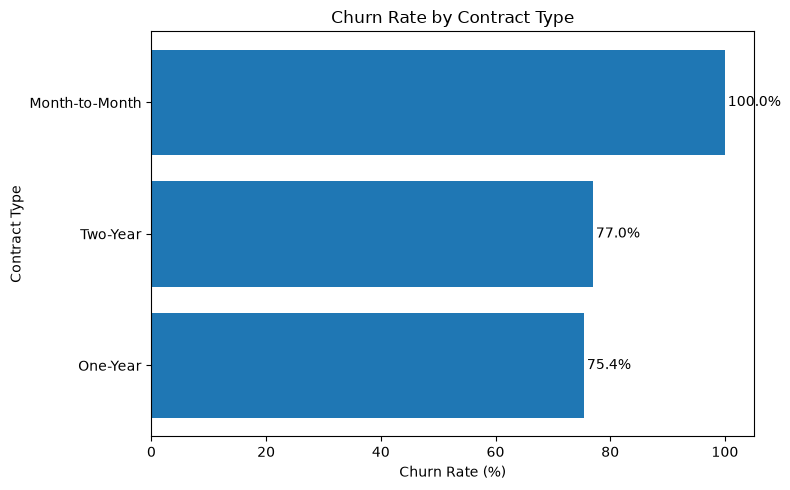

In [67]:
# Plot churn by contract

plot_data = contract_churn.sort_values(
    "ChurnRate",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["ContractType"].astype(str),
    plot_data["ChurnRate"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Contract Type")

for index, value in enumerate(plot_data["ChurnRate"]):
    plt.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

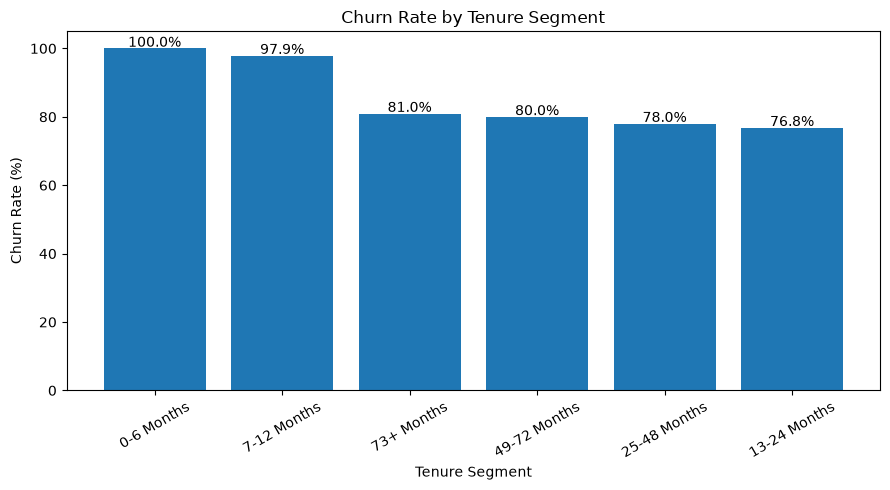

In [68]:
# Plot churn by tenure

plot_data = tenure_churn.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    plot_data["TenureSegment"].astype(str),
    plot_data["ChurnRate"]
)

plt.title("Churn Rate by Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

for index, value in enumerate(plot_data["ChurnRate"]):
    plt.text(
        index,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [69]:
# Export churn summary tables

EDA_OUTPUT_DIR = Path("../data/processed/eda")
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_tables = {
    "churn_by_contract.csv": contract_churn,
    "churn_by_internet_service.csv": internet_churn,
    "churn_by_tech_support.csv": support_churn,
    "churn_by_tenure.csv": tenure_churn,
    "churn_by_age_group.csv": age_churn,
    "churn_by_charge_band.csv": charge_churn,
    "churn_by_lifecycle.csv": lifecycle_churn
}

for file_name, summary_df in summary_tables.items():
    summary_df.to_csv(
        EDA_OUTPUT_DIR / file_name,
        index=False
    )

print(f"Exported {len(summary_tables)} EDA summary tables.")

Exported 7 EDA summary tables.


In [70]:
# Print key EDA results

print("=" * 70)
print("OVERALL CHURN")
print("=" * 70)
print(overall_churn_summary.to_string(index=False))

print("\n" + "=" * 70)
print("CHURN BY CONTRACT")
print("=" * 70)
print(contract_churn.to_string(index=False))

print("\n" + "=" * 70)
print("CHURN BY INTERNET SERVICE")
print("=" * 70)
print(internet_churn.to_string(index=False))

print("\n" + "=" * 70)
print("CHURN BY TECH SUPPORT")
print("=" * 70)
print(support_churn.to_string(index=False))

print("\n" + "=" * 70)
print("CHURN BY TENURE")
print("=" * 70)
print(tenure_churn.to_string(index=False))

print("\n" + "=" * 70)
print("CHURN BY CHARGE BAND")
print("=" * 70)
print(charge_churn.to_string(index=False))

print("\n" + "=" * 70)
print("REVENUE LOSS SUMMARY")
print("=" * 70)
print(revenue_loss_summary.to_string(index=False))

OVERALL CHURN
            Metric  Value
   Total Customers   1000
 Churned Customers    883
Retained Customers    117
        Churn Rate 88.30%

CHURN BY CONTRACT
  ContractType  Customers  ChurnedCustomers  AverageMonthlyCharges  TotalMonthlyRevenue  ChurnRate  ChurnedMonthlyRevenue
Month-to-Month        511               511                  75.91            38,789.60     100.00              38,789.60
      Two-Year        200               154                  71.33            14,266.90      77.00              11,359.04
      One-Year        289               218                  73.82            21,334.79      75.43              16,924.72

CHURN BY INTERNET SERVICE
InternetService  Customers  ChurnedCustomers  AverageMonthlyCharges  TotalMonthlyRevenue  ChurnRate  ChurnedMonthlyRevenue
    No Internet        297               297                  75.79            22,508.48     100.00              22,508.48
            DSL        308               260                  72.16         

## Leakage and Predictive Signal Assessment

This section checks whether any customer attributes almost perfectly determine churn and evaluates whether a machine-learning model would provide meaningful additional value.

In [71]:
# Measure churn separation

leakage_columns = [
    "ContractType",
    "InternetService",
    "TechSupport",
    "TenureSegment",
    "MonthlyChargeBand",
    "CustomerLifecycleStage"
]

leakage_results = []

for column in leakage_columns:
    summary = (
        df_clean.groupby(column, observed=False)["ChurnFlag"]
        .agg(["count", "mean"])
        .reset_index()
    )

    summary["ChurnRate"] = summary["mean"] * 100
    summary["PerfectRule"] = summary["ChurnRate"].isin([0, 100])
    summary["Feature"] = column

    leakage_results.append(
        summary[
            [
                "Feature",
                column,
                "count",
                "ChurnRate",
                "PerfectRule"
            ]
        ].rename(columns={column: "Category"})
    )

leakage_summary = pd.concat(
    leakage_results,
    ignore_index=True
)

leakage_summary

,Feature,Category,count,ChurnRate,PerfectRule
0,ContractType,Month-to-Month,511,100.00,True
1,ContractType,One-Year,289,75.43,False
2,ContractType,Two-Year,200,77.00,False
3,InternetService,DSL,308,84.42,False
4,InternetService,Fiber Optic,395,82.53,False
5,InternetService,No Internet,297,100.00,True
6,TechSupport,No,494,100.00,True
7,TechSupport,Yes,506,76.88,False
8,TenureSegment,0-6 Months,300,100.00,True
9,TenureSegment,7-12 Months,190,97.89,False


In [72]:
# Show perfect churn rules

perfect_rules = leakage_summary[
    leakage_summary["PerfectRule"]
].sort_values(
    ["Feature", "ChurnRate"],
    ascending=[True, False]
)

perfect_rules

,Feature,Category,count,ChurnRate,PerfectRule
0,ContractType,Month-to-Month,511,100.00,True
21,CustomerLifecycleStage,New,300,100.00,True
5,InternetService,No Internet,297,100.00,True
17,MonthlyChargeBand,Premium,211,100.00,True
6,TechSupport,No,494,100.00,True
8,TenureSegment,0-6 Months,300,100.00,True


In [73]:
# Compare single-feature accuracy

from sklearn.metrics import accuracy_score

rule_predictions = pd.DataFrame({
    "ActualChurn": df_clean["ChurnFlag"]
})

rule_predictions["PredictMonthToMonth"] = (
    df_clean["ContractType"] == "Month-to-Month"
).astype(int)

rule_predictions["PredictNoTechSupport"] = (
    df_clean["TechSupport"] == "No"
).astype(int)

rule_predictions["PredictNewCustomer"] = (
    df_clean["Tenure"] <= 6
).astype(int)

rule_predictions["PredictPremiumCharge"] = (
    df_clean["MonthlyChargeBand"] == "Premium"
).astype(int)

rule_accuracy = []

for column in rule_predictions.columns[1:]:
    rule_accuracy.append({
        "Rule": column,
        "Accuracy": accuracy_score(
            rule_predictions["ActualChurn"],
            rule_predictions[column]
        )
    })

rule_accuracy_df = pd.DataFrame(
    rule_accuracy
).sort_values(
    "Accuracy",
    ascending=False
)

rule_accuracy_df

,Rule,Accuracy
0,PredictMonthToMonth,0.63
1,PredictNoTechSupport,0.61
2,PredictNewCustomer,0.42
3,PredictPremiumCharge,0.33


In [74]:
# Check combined synthetic rules

rule_predictions["CombinedRulePrediction"] = (
    (df_clean["ContractType"] == "Month-to-Month") |
    (df_clean["TechSupport"] == "No") |
    (df_clean["Tenure"] <= 6) |
    (df_clean["MonthlyChargeBand"] == "Premium")
).astype(int)

combined_rule_accuracy = accuracy_score(
    rule_predictions["ActualChurn"],
    rule_predictions["CombinedRulePrediction"]
)

print(
    f"Combined rule accuracy: "
    f"{combined_rule_accuracy:.2%}"
)

Combined rule accuracy: 96.50%


In [75]:
# Create leakage summary

leakage_assessment = pd.DataFrame({
    "Metric": [
        "Perfect category-level churn rules",
        "Combined rule accuracy",
        "Dataset churn rate",
        "Modeling risk"
    ],
    "Value": [
        int(perfect_rules.shape[0]),
        f"{combined_rule_accuracy:.2%}",
        f'{df_clean["ChurnFlag"].mean():.2%}',
        "High risk of synthetic patterns and inflated model performance"
    ]
})

leakage_assessment

,Metric,Value
0,Perfect category-level churn rules,6
1,Combined rule accuracy,96.50%
2,Dataset churn rate,88.30%
3,Modeling risk,High risk of synthetic patterns and inflated m...


In [76]:
# Print leakage results

print("=" * 70)
print("PERFECT CHURN RULES")
print("=" * 70)
print(perfect_rules.to_string(index=False))

print("\n" + "=" * 70)
print("SINGLE RULE ACCURACY")
print("=" * 70)
print(rule_accuracy_df.to_string(index=False))

print("\n" + "=" * 70)
print("COMBINED RULE ACCURACY")
print("=" * 70)
print(f"{combined_rule_accuracy:.2%}")

PERFECT CHURN RULES
               Feature       Category  count  ChurnRate  PerfectRule
          ContractType Month-to-Month    511     100.00         True
CustomerLifecycleStage            New    300     100.00         True
       InternetService    No Internet    297     100.00         True
     MonthlyChargeBand        Premium    211     100.00         True
           TechSupport             No    494     100.00         True
         TenureSegment     0-6 Months    300     100.00         True

SINGLE RULE ACCURACY
                Rule  Accuracy
 PredictMonthToMonth      0.63
PredictNoTechSupport      0.61
  PredictNewCustomer      0.42
PredictPremiumCharge      0.33

COMBINED RULE ACCURACY
96.50%


## Churn Modeling Benchmark

This section compares transparent business rules with logistic regression and random forest models. Because the dataset contains synthetic churn patterns, model results are treated as portfolio benchmarks rather than production-ready estimates.

In [77]:
# Import modeling libraries

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [78]:
# Define modeling features

model_features = [
    "Age",
    "Tenure",
    "MonthlyCharges",
    "Gender",
    "ContractType",
    "InternetService",
    "TechSupport"
]

target_column = "ChurnFlag"

X = df_clean[model_features].copy()
y = df_clean[target_column].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True).sort_index())

Feature shape: (1000, 7)
Target shape: (1000,)

Target distribution:
ChurnFlag
0   0.12
1   0.88
Name: proportion, dtype: float64


In [79]:
# Split training and test data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Test churn rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 800
Test rows: 200

Training churn rate: 88.25 %
Test churn rate: 88.5 %


In [80]:
# Define preprocessing

numeric_features = [
    "Age",
    "Tenure",
    "MonthlyCharges"
]

categorical_features = [
    "Gender",
    "ContractType",
    "InternetService",
    "TechSupport"
]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [81]:
# Build logistic regression model

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [82]:
# Train logistic regression model

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic regression training complete.")

Logistic regression training complete.


In [83]:
# Evaluate logistic regression model

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

logistic_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        logistic_predictions
    ),
    "Precision": precision_score(
        y_test,
        logistic_predictions
    ),
    "Recall": recall_score(
        y_test,
        logistic_predictions
    ),
    "F1Score": f1_score(
        y_test,
        logistic_predictions
    ),
    "ROCAUC": roc_auc_score(
        y_test,
        logistic_probabilities
    )
}

pd.DataFrame([logistic_metrics])

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC
0,Logistic Regression,0.94,1.00,0.93,0.96,0.99


In [84]:
# Show logistic confusion matrix

logistic_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_test,
        logistic_predictions
    ),
    index=[
        "Actual No Churn",
        "Actual Churn"
    ],
    columns=[
        "Predicted No Churn",
        "Predicted Churn"
    ]
)

logistic_confusion_matrix

,Predicted No Churn,Predicted Churn
Actual No Churn,23,0
Actual Churn,13,164


In [85]:
# Show logistic classification report

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.64      1.00      0.78        23
       Churn       1.00      0.93      0.96       177

    accuracy                           0.94       200
   macro avg       0.82      0.96      0.87       200
weighted avg       0.96      0.94      0.94       200



In [86]:
# Build random forest model

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [87]:
# Train random forest model

random_forest_model.fit(
    X_train,
    y_train
)

print("Random forest training complete.")

Random forest training complete.


In [88]:
# Evaluate random forest model

forest_predictions = random_forest_model.predict(X_test)
forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

forest_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(
        y_test,
        forest_predictions
    ),
    "Precision": precision_score(
        y_test,
        forest_predictions
    ),
    "Recall": recall_score(
        y_test,
        forest_predictions
    ),
    "F1Score": f1_score(
        y_test,
        forest_predictions
    ),
    "ROCAUC": roc_auc_score(
        y_test,
        forest_probabilities
    )
}

pd.DataFrame([forest_metrics])

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC
0,Random Forest,1.00,1.00,1.00,1.00,1.00


In [89]:
# Show random forest confusion matrix

forest_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_test,
        forest_predictions
    ),
    index=[
        "Actual No Churn",
        "Actual Churn"
    ],
    columns=[
        "Predicted No Churn",
        "Predicted Churn"
    ]
)

forest_confusion_matrix

,Predicted No Churn,Predicted Churn
Actual No Churn,23,0
Actual Churn,0,177


In [90]:
# Show random forest classification report

print(
    classification_report(
        y_test,
        forest_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00        23
       Churn       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [91]:
# Calculate combined rule test metrics

test_rule_predictions = (
    (X_test["ContractType"] == "Month-to-Month") |
    (X_test["TechSupport"] == "No") |
    (X_test["Tenure"] <= 6) |
    (X_test["MonthlyCharges"] > 100)
).astype(int)

rule_metrics = {
    "Model": "Combined Business Rule",
    "Accuracy": accuracy_score(
        y_test,
        test_rule_predictions
    ),
    "Precision": precision_score(
        y_test,
        test_rule_predictions
    ),
    "Recall": recall_score(
        y_test,
        test_rule_predictions
    ),
    "F1Score": f1_score(
        y_test,
        test_rule_predictions
    ),
    "ROCAUC": np.nan
}

In [92]:
# Compare model performance

model_comparison = pd.DataFrame([
    rule_metrics,
    logistic_metrics,
    forest_metrics
])

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1Score",
    "ROCAUC"
]

model_comparison[metric_columns] = (
    model_comparison[metric_columns] * 100
)

model_comparison.round(2)

,Model,Accuracy,Precision,Recall,F1Score,ROCAUC
0,Combined Business Rule,97.50,100.00,97.18,98.57,NaN
1,Logistic Regression,93.50,100.00,92.66,96.19,99.07
2,Random Forest,100.00,100.00,100.00,100.00,100.00


In [93]:
# Select best predictive model

predictive_models = model_comparison[
    model_comparison["Model"] != "Combined Business Rule"
].copy()

best_model_name = (
    predictive_models
    .sort_values(
        "ROCAUC",
        ascending=False
    )
    .iloc[0]["Model"]
)

if best_model_name == "Logistic Regression":
    best_model = logistic_model
else:
    best_model = random_forest_model

print("Selected model:", best_model_name)

Selected model: Random Forest


In [94]:
# Print model results

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(
    model_comparison
    .round(2)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("LOGISTIC CONFUSION MATRIX")
print("=" * 70)
print(logistic_confusion_matrix)

print("\n" + "=" * 70)
print("RANDOM FOREST CONFUSION MATRIX")
print("=" * 70)
print(forest_confusion_matrix)

print("\n" + "=" * 70)
print("SELECTED MODEL")
print("=" * 70)
print(best_model_name)

MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1Score  ROCAUC
Combined Business Rule     97.50     100.00   97.18    98.57     NaN
   Logistic Regression     93.50     100.00   92.66    96.19   99.07
         Random Forest    100.00     100.00  100.00   100.00  100.00

LOGISTIC CONFUSION MATRIX
                 Predicted No Churn  Predicted Churn
Actual No Churn                  23                0
Actual Churn                     13              164

RANDOM FOREST CONFUSION MATRIX
                 Predicted No Churn  Predicted Churn
Actual No Churn                  23                0
Actual Churn                      0              177

SELECTED MODEL
Random Forest


## Customer Risk Scoring

The selected model is used to assign churn probabilities, risk bands, and revenue-at-risk estimates to every customer.

In [95]:
# Generate churn probabilities

df_scored = df_clean.copy()

df_scored["ChurnProbability"] = (
    best_model.predict_proba(
        df_scored[model_features]
    )[:, 1]
)

df_scored[
    [
        "CustomerID",
        "Churn",
        "ChurnProbability"
    ]
].head()

,CustomerID,Churn,ChurnProbability
0,1,Yes,1.00
1,2,Yes,1.00
2,3,Yes,1.00
3,4,Yes,0.94
4,5,Yes,1.00


In [96]:
# Create churn risk bands

df_scored["RiskBand"] = pd.cut(
    df_scored["ChurnProbability"],
    bins=[-0.01, 0.30, 0.55, 0.75, 1.00],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

df_scored["RiskBand"].value_counts(
    dropna=False
)

RiskBand
Critical    867
Low         117
High         16
Medium        0
Name: count, dtype: int64

In [97]:
# Calculate revenue at risk

df_scored["MonthlyRevenueAtRisk"] = (
    df_scored["MonthlyCharges"] *
    df_scored["ChurnProbability"]
)

df_scored["AnnualRevenueAtRisk"] = (
    df_scored["MonthlyRevenueAtRisk"] * 12
)

In [98]:
# Normalize value features

from sklearn.preprocessing import MinMaxScaler

value_features = [
    "MonthlyCharges",
    "TotalCharges",
    "Tenure"
]

value_scaler = MinMaxScaler()

normalized_values = value_scaler.fit_transform(
    df_scored[value_features]
)

normalized_value_df = pd.DataFrame(
    normalized_values,
    columns=[
        "MonthlyChargesNormalized",
        "TotalChargesNormalized",
        "TenureNormalized"
    ],
    index=df_scored.index
)

df_scored = pd.concat(
    [
        df_scored,
        normalized_value_df
    ],
    axis=1
)

In [99]:
# Calculate customer value score

df_scored["CustomerValueScore"] = (
    0.40 * df_scored["MonthlyChargesNormalized"] +
    0.35 * df_scored["TotalChargesNormalized"] +
    0.25 * df_scored["TenureNormalized"]
)

df_scored["CustomerValueScore"].describe()

count   1,000.00
mean        0.28
std         0.15
min         0.00
25%         0.16
50%         0.27
75%         0.38
max         0.96
Name: CustomerValueScore, dtype: float64

In [100]:
# Create customer value tiers

df_scored["ValueTier"] = pd.qcut(
    df_scored["CustomerValueScore"],
    q=4,
    labels=[
        "Low Value",
        "Moderate Value",
        "High Value",
        "Top Value"
    ],
    duplicates="drop"
)

df_scored["ValueTier"].value_counts()

ValueTier
Low Value         250
Moderate Value    250
High Value        250
Top Value         250
Name: count, dtype: int64

In [101]:
# Calculate retention priority

df_scored["RetentionPriorityScore"] = (
    0.60 * df_scored["ChurnProbability"] +
    0.40 * df_scored["CustomerValueScore"]
)

df_scored["RetentionPriorityRank"] = (
    df_scored["RetentionPriorityScore"]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

In [102]:
# Create priority tiers

df_scored["PriorityTier"] = pd.cut(
    df_scored["RetentionPriorityScore"],
    bins=[-0.01, 0.40, 0.60, 0.80, 1.00],
    labels=[
        "Monitor",
        "Medium Priority",
        "High Priority",
        "Immediate Action"
    ]
)

df_scored["PriorityTier"].value_counts(
    dropna=False
)

PriorityTier
High Priority       753
Monitor             117
Medium Priority      75
Immediate Action     55
Name: count, dtype: int64

In [103]:
# Recommend retention actions

def recommend_retention_action(row):
    if (
        row["RiskBand"] == "Critical"
        and row["CustomerValueScore"] >= 0.70
    ):
        return "Priority Retention Specialist"

    if (
        row["RiskBand"] in ["Critical", "High"]
        and row["ContractType"] == "Month-to-Month"
    ):
        return "Contract Upgrade Offer"

    if (
        row["RiskBand"] in ["Critical", "High"]
        and row["TechSupport"] == "No"
    ):
        return "Complimentary Tech Support"

    if (
        row["RiskBand"] in ["Critical", "High"]
        and row["Tenure"] <= 6
    ):
        return "New Customer Onboarding Call"

    if (
        row["RiskBand"] in ["Critical", "High"]
        and row["MonthlyCharges"] >= 100
    ):
        return "Billing Review and Discount"

    if row["RiskBand"] == "Medium":
        return "Personalized Retention Email"

    return "No Immediate Action"


df_scored["RecommendedAction"] = (
    df_scored.apply(
        recommend_retention_action,
        axis=1
    )
)

df_scored["RecommendedAction"].value_counts()

RecommendedAction
Contract Upgrade Offer           503
Complimentary Tech Support       227
No Immediate Action              152
New Customer Onboarding Call      75
Billing Review and Discount       33
Priority Retention Specialist     10
Name: count, dtype: int64

In [104]:
# Define campaign assumptions

campaign_assumptions = {
    "Priority Retention Specialist": {
        "InterventionCost": 60,
        "ExpectedSuccessRate": 0.25
    },
    "Contract Upgrade Offer": {
        "InterventionCost": 40,
        "ExpectedSuccessRate": 0.20
    },
    "Complimentary Tech Support": {
        "InterventionCost": 20,
        "ExpectedSuccessRate": 0.15
    },
    "New Customer Onboarding Call": {
        "InterventionCost": 10,
        "ExpectedSuccessRate": 0.08
    },
    "Billing Review and Discount": {
        "InterventionCost": 30,
        "ExpectedSuccessRate": 0.15
    },
    "Personalized Retention Email": {
        "InterventionCost": 2,
        "ExpectedSuccessRate": 0.03
    },
    "No Immediate Action": {
        "InterventionCost": 0,
        "ExpectedSuccessRate": 0.00
    }
}

In [105]:
# Map campaign assumptions

df_scored["InterventionCost"] = (
    df_scored["RecommendedAction"]
    .map(
        lambda action: campaign_assumptions[action][
            "InterventionCost"
        ]
    )
)

df_scored["ExpectedSuccessRate"] = (
    df_scored["RecommendedAction"]
    .map(
        lambda action: campaign_assumptions[action][
            "ExpectedSuccessRate"
        ]
    )
)

In [106]:
# Calculate campaign economics

df_scored["ExpectedRevenueProtected"] = (
    df_scored["AnnualRevenueAtRisk"] *
    df_scored["ExpectedSuccessRate"]
)

df_scored["ExpectedNetBenefit"] = (
    df_scored["ExpectedRevenueProtected"] -
    df_scored["InterventionCost"]
)

df_scored["ExpectedROI"] = np.where(
    df_scored["InterventionCost"] > 0,
    df_scored["ExpectedNetBenefit"] /
    df_scored["InterventionCost"],
    0
)

In [107]:
# Rank campaign candidates

df_scored = df_scored.sort_values(
    [
        "ExpectedNetBenefit",
        "RetentionPriorityScore"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

df_scored["CampaignRank"] = (
    np.arange(
        1,
        len(df_scored) + 1
    )
)

df_scored["CumulativeCampaignCost"] = (
    df_scored["InterventionCost"]
    .cumsum()
)

In [108]:
# Preview top retention candidates

retention_columns = [
    "CampaignRank",
    "CustomerID",
    "ChurnProbability",
    "RiskBand",
    "CustomerValueScore",
    "ValueTier",
    "RetentionPriorityScore",
    "PriorityTier",
    "AnnualRevenueAtRisk",
    "RecommendedAction",
    "InterventionCost",
    "ExpectedRevenueProtected",
    "ExpectedNetBenefit",
    "ExpectedROI",
    "CumulativeCampaignCost"
]

df_scored[retention_columns].head(20)

,CampaignRank,CustomerID,ChurnProbability,RiskBand,CustomerValueScore,ValueTier,RetentionPriorityScore,PriorityTier,AnnualRevenueAtRisk,RecommendedAction,InterventionCost,ExpectedRevenueProtected,ExpectedNetBenefit,ExpectedROI,CumulativeCampaignCost
0,1,764,1.00,Critical,0.72,Top Value,0.89,Immediate Action,"1,431.36",Priority Retention Specialist,60,357.84,297.84,4.96,60
1,2,508,1.00,Critical,0.74,Top Value,0.90,Immediate Action,"1,422.24",Priority Retention Specialist,60,355.56,295.56,4.93,120
2,3,618,0.99,Critical,0.76,Top Value,0.90,Immediate Action,"1,401.30",Priority Retention Specialist,60,350.33,290.33,4.84,180
3,4,510,1.00,Critical,0.79,Top Value,0.91,Immediate Action,"1,400.39",Priority Retention Specialist,60,350.10,290.10,4.83,240
4,5,494,0.99,Critical,0.96,Top Value,0.97,Immediate Action,"1,399.11",Priority Retention Specialist,60,349.78,289.78,4.83,300
5,6,772,0.98,Critical,0.75,Top Value,0.89,Immediate Action,"1,394.85",Priority Retention Specialist,60,348.71,288.71,4.81,360
6,7,541,1.00,Critical,0.89,Top Value,0.96,Immediate Action,"1,365.64",Priority Retention Specialist,60,341.41,281.41,4.69,420
7,8,341,1.00,Critical,0.72,Top Value,0.89,Immediate Action,"1,354.44",Priority Retention Specialist,60,338.61,278.61,4.64,480
8,9,690,0.99,Critical,0.73,Top Value,0.88,Immediate Action,"1,348.55",Priority Retention Specialist,60,337.14,277.14,4.62,540
9,10,354,1.00,Critical,0.47,Top Value,0.79,High Priority,"1,439.52",Contract Upgrade Offer,40,287.90,247.90,6.20,580


In [109]:
# Summarize campaign actions

campaign_summary = (
    df_scored.groupby(
        "RecommendedAction",
        observed=False
    )
    .agg(
        Customers=("CustomerID", "count"),
        CampaignCost=("InterventionCost", "sum"),
        AnnualRevenueAtRisk=("AnnualRevenueAtRisk", "sum"),
        ExpectedRevenueProtected=(
            "ExpectedRevenueProtected",
            "sum"
        ),
        ExpectedNetBenefit=(
            "ExpectedNetBenefit",
            "sum"
        )
    )
    .reset_index()
)

campaign_summary["ExpectedROI"] = np.where(
    campaign_summary["CampaignCost"] > 0,
    campaign_summary["ExpectedNetBenefit"] /
    campaign_summary["CampaignCost"],
    0
)

campaign_summary.sort_values(
    "ExpectedNetBenefit",
    ascending=False
)

,RecommendedAction,Customers,CampaignCost,AnnualRevenueAtRisk,ExpectedRevenueProtected,ExpectedNetBenefit,ExpectedROI
2,Contract Upgrade Offer,503,20120,"451,013.92","90,202.78","70,082.78",3.48
1,Complimentary Tech Support,227,4540,"199,402.04","29,910.31","25,370.31",5.59
3,New Customer Onboarding Call,75,750,"59,244.04","4,739.52","3,989.52",5.32
0,Billing Review and Discount,33,990,"33,129.42","4,969.41","3,979.41",4.02
5,Priority Retention Specialist,10,600,"13,728.16","3,432.04","2,832.04",4.72
4,No Immediate Action,152,0,"24,820.46",0.00,0.00,0.00


In [110]:
# Save customer scoring output

SCORED_DATA_PATH = (
    PROCESSED_DATA_DIR /
    "customer_retention_scores.csv"
)

df_scored.to_csv(
    SCORED_DATA_PATH,
    index=False
)

print(f"Scored dataset saved to: {SCORED_DATA_PATH}")
print(f"Rows saved: {len(df_scored):,}")
print(f"Columns saved: {df_scored.shape[1]}")

Scored dataset saved to: ../data/processed/customer_retention_scores.csv
Rows saved: 1,000
Columns saved: 40


In [111]:
# Save campaign summary

CAMPAIGN_SUMMARY_PATH = (
    PROCESSED_DATA_DIR /
    "campaign_summary.csv"
)

campaign_summary.to_csv(
    CAMPAIGN_SUMMARY_PATH,
    index=False
)

print(
    f"Campaign summary saved to: "
    f"{CAMPAIGN_SUMMARY_PATH}"
)

Campaign summary saved to: ../data/processed/campaign_summary.csv


In [112]:
# Print scoring results

print("=" * 70)
print("RISK BAND DISTRIBUTION")
print("=" * 70)
print(
    df_scored["RiskBand"]
    .value_counts(dropna=False)
    .to_string()
)

print("\n" + "=" * 70)
print("PRIORITY TIER DISTRIBUTION")
print("=" * 70)
print(
    df_scored["PriorityTier"]
    .value_counts(dropna=False)
    .to_string()
)

print("\n" + "=" * 70)
print("RECOMMENDED ACTION DISTRIBUTION")
print("=" * 70)
print(
    df_scored["RecommendedAction"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 70)
print("CAMPAIGN SUMMARY")
print("=" * 70)
print(
    campaign_summary
    .round(2)
    .sort_values(
        "ExpectedNetBenefit",
        ascending=False
    )
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP 10 RETENTION CANDIDATES")
print("=" * 70)
print(
    df_scored[
        [
            "CampaignRank",
            "CustomerID",
            "ChurnProbability",
            "RiskBand",
            "CustomerValueScore",
            "RecommendedAction",
            "AnnualRevenueAtRisk",
            "ExpectedNetBenefit"
        ]
    ]
    .head(10)
    .round(2)
    .to_string(index=False)
)

RISK BAND DISTRIBUTION
RiskBand
Critical    867
Low         117
High         16
Medium        0

PRIORITY TIER DISTRIBUTION
PriorityTier
High Priority       753
Monitor             117
Medium Priority      75
Immediate Action     55

RECOMMENDED ACTION DISTRIBUTION
RecommendedAction
Contract Upgrade Offer           503
Complimentary Tech Support       227
No Immediate Action              152
New Customer Onboarding Call      75
Billing Review and Discount       33
Priority Retention Specialist     10

CAMPAIGN SUMMARY
            RecommendedAction  Customers  CampaignCost  AnnualRevenueAtRisk  ExpectedRevenueProtected  ExpectedNetBenefit  ExpectedROI
       Contract Upgrade Offer        503         20120           451,013.92                 90,202.78           70,082.78         3.48
   Complimentary Tech Support        227          4540           199,402.04                 29,910.31           25,370.31         5.59
 New Customer Onboarding Call         75           750            59,24

## Campaign-Oriented Risk Segmentation

Because model probabilities are highly polarized, percentile-based risk tiers are used to create practical customer segments for campaign prioritization.

In [113]:
# Create percentile risk tiers

df_scored["CampaignRiskTier"] = pd.qcut(
    df_scored["ChurnProbability"].rank(method="first"),
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

df_scored["CampaignRiskTier"].value_counts()

CampaignRiskTier
Low         250
Medium      250
High        250
Critical    250
Name: count, dtype: int64

In [114]:
# Recommend campaign actions

def recommend_campaign_action(row):
    if row["CampaignRiskTier"] == "Critical":
        if row["CustomerValueScore"] >= 0.70:
            return "Priority Retention Specialist"

        if row["ContractType"] == "Month-to-Month":
            return "Contract Upgrade Offer"

        if row["TechSupport"] == "No":
            return "Complimentary Tech Support"

        if row["Tenure"] <= 6:
            return "New Customer Onboarding Call"

        return "Billing Review and Discount"

    if row["CampaignRiskTier"] == "High":
        if row["ContractType"] == "Month-to-Month":
            return "Contract Upgrade Offer"

        if row["TechSupport"] == "No":
            return "Complimentary Tech Support"

        return "Personalized Retention Email"

    if row["CampaignRiskTier"] == "Medium":
        return "Personalized Retention Email"

    return "No Immediate Action"


df_scored["RecommendedAction"] = df_scored.apply(
    recommend_campaign_action,
    axis=1
)

df_scored["RecommendedAction"].value_counts()

RecommendedAction
Contract Upgrade Offer          359
Personalized Retention Email    250
No Immediate Action             250
Complimentary Tech Support      141
Name: count, dtype: int64

In [115]:
# Refresh campaign assumptions

campaign_assumptions = {
    "Priority Retention Specialist": {
        "InterventionCost": 60,
        "ExpectedSuccessRate": 0.25
    },
    "Contract Upgrade Offer": {
        "InterventionCost": 40,
        "ExpectedSuccessRate": 0.20
    },
    "Complimentary Tech Support": {
        "InterventionCost": 20,
        "ExpectedSuccessRate": 0.15
    },
    "New Customer Onboarding Call": {
        "InterventionCost": 10,
        "ExpectedSuccessRate": 0.08
    },
    "Billing Review and Discount": {
        "InterventionCost": 30,
        "ExpectedSuccessRate": 0.15
    },
    "Personalized Retention Email": {
        "InterventionCost": 2,
        "ExpectedSuccessRate": 0.03
    },
    "No Immediate Action": {
        "InterventionCost": 0,
        "ExpectedSuccessRate": 0.00
    }
}

In [116]:
# Map campaign economics

df_scored["InterventionCost"] = (
    df_scored["RecommendedAction"]
    .map(
        lambda action:
        campaign_assumptions[action]["InterventionCost"]
    )
)

df_scored["ExpectedSuccessRate"] = (
    df_scored["RecommendedAction"]
    .map(
        lambda action:
        campaign_assumptions[action]["ExpectedSuccessRate"]
    )
)

df_scored["ExpectedRevenueProtected"] = (
    df_scored["AnnualRevenueAtRisk"] *
    df_scored["ExpectedSuccessRate"]
)

df_scored["ExpectedNetBenefit"] = (
    df_scored["ExpectedRevenueProtected"] -
    df_scored["InterventionCost"]
)

df_scored["ExpectedROI"] = np.where(
    df_scored["InterventionCost"] > 0,
    df_scored["ExpectedNetBenefit"] /
    df_scored["InterventionCost"],
    0
)

In [117]:
# Rank retention candidates

df_scored = df_scored.sort_values(
    [
        "ExpectedNetBenefit",
        "RetentionPriorityScore"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

df_scored["CampaignRank"] = (
    np.arange(1, len(df_scored) + 1)
)

df_scored["CumulativeCampaignCost"] = (
    df_scored["InterventionCost"].cumsum()
)

df_scored["CumulativeExpectedRevenueProtected"] = (
    df_scored["ExpectedRevenueProtected"].cumsum()
)

df_scored["CumulativeExpectedNetBenefit"] = (
    df_scored["ExpectedNetBenefit"].cumsum()
)

In [118]:
# Create budget scenarios

campaign_budgets = [
    1000,
    2500,
    5000,
    10000,
    20000
]

budget_results = []

for budget in campaign_budgets:
    selected_customers = df_scored[
        df_scored["CumulativeCampaignCost"] <= budget
    ]

    budget_results.append({
        "CampaignBudget": budget,
        "CustomersTargeted": len(selected_customers),
        "CampaignCost": selected_customers[
            "InterventionCost"
        ].sum(),
        "AnnualRevenueAtRisk": selected_customers[
            "AnnualRevenueAtRisk"
        ].sum(),
        "ExpectedRevenueProtected": selected_customers[
            "ExpectedRevenueProtected"
        ].sum(),
        "ExpectedNetBenefit": selected_customers[
            "ExpectedNetBenefit"
        ].sum()
    })

budget_scenarios = pd.DataFrame(budget_results)

budget_scenarios["ExpectedROI"] = np.where(
    budget_scenarios["CampaignCost"] > 0,
    budget_scenarios["ExpectedNetBenefit"] /
    budget_scenarios["CampaignCost"],
    0
)

budget_scenarios.round(2)

,CampaignBudget,CustomersTargeted,CampaignCost,AnnualRevenueAtRisk,ExpectedRevenueProtected,ExpectedNetBenefit,ExpectedROI
0,1000,25,1000,"35,105.44","7,021.09","6,021.09",6.02
1,2500,62,2480,"83,758.09","16,751.62","14,271.62",5.75
2,5000,132,5000,"168,675.88","32,790.20","27,790.20",5.56
3,10000,287,9980,"327,112.19","61,039.44","51,059.44",5.12
4,20000,1000,17680,"781,338.05","91,784.99","74,104.99",4.19


In [119]:
# Summarize retention actions

campaign_summary = (
    df_scored.groupby(
        "RecommendedAction",
        observed=False
    )
    .agg(
        Customers=("CustomerID", "count"),
        CampaignCost=("InterventionCost", "sum"),
        AnnualRevenueAtRisk=(
            "AnnualRevenueAtRisk",
            "sum"
        ),
        ExpectedRevenueProtected=(
            "ExpectedRevenueProtected",
            "sum"
        ),
        ExpectedNetBenefit=(
            "ExpectedNetBenefit",
            "sum"
        )
    )
    .reset_index()
)

campaign_summary["ExpectedROI"] = np.where(
    campaign_summary["CampaignCost"] > 0,
    campaign_summary["ExpectedNetBenefit"] /
    campaign_summary["CampaignCost"],
    0
)

campaign_summary.sort_values(
    "ExpectedNetBenefit",
    ascending=False
)

,RecommendedAction,Customers,CampaignCost,AnnualRevenueAtRisk,ExpectedRevenueProtected,ExpectedNetBenefit,ExpectedROI
1,Contract Upgrade Offer,359,14360,"327,204.43","65,440.89","51,080.89",3.56
0,Complimentary Tech Support,141,2820,"131,219.38","19,682.91","16,862.91",5.98
3,Personalized Retention Email,250,500,"222,040.02","6,661.20","6,161.20",12.32
2,No Immediate Action,250,0,"100,874.21",0.00,0.00,0.00


In [120]:
# Save final scoring outputs

df_scored.to_csv(
    PROCESSED_DATA_DIR /
    "customer_retention_scores.csv",
    index=False
)

campaign_summary.to_csv(
    PROCESSED_DATA_DIR /
    "campaign_summary.csv",
    index=False
)

budget_scenarios.to_csv(
    PROCESSED_DATA_DIR /
    "campaign_budget_scenarios.csv",
    index=False
)

print("Final dashboard datasets saved successfully.")

Final dashboard datasets saved successfully.


In [121]:
# Print campaign results

print("=" * 70)
print("CAMPAIGN RISK TIERS")
print("=" * 70)
print(
    df_scored["CampaignRiskTier"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 70)
print("RECOMMENDED ACTIONS")
print("=" * 70)
print(
    df_scored["RecommendedAction"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 70)
print("BUDGET SCENARIOS")
print("=" * 70)
print(
    budget_scenarios
    .round(2)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("CAMPAIGN SUMMARY")
print("=" * 70)
print(
    campaign_summary
    .round(2)
    .sort_values(
        "ExpectedNetBenefit",
        ascending=False
    )
    .to_string(index=False)
)

CAMPAIGN RISK TIERS
CampaignRiskTier
Low         250
Medium      250
High        250
Critical    250

RECOMMENDED ACTIONS
RecommendedAction
Contract Upgrade Offer          359
Personalized Retention Email    250
No Immediate Action             250
Complimentary Tech Support      141

BUDGET SCENARIOS
 CampaignBudget  CustomersTargeted  CampaignCost  AnnualRevenueAtRisk  ExpectedRevenueProtected  ExpectedNetBenefit  ExpectedROI
           1000                 25          1000            35,105.44                  7,021.09            6,021.09         6.02
           2500                 62          2480            83,758.09                 16,751.62           14,271.62         5.75
           5000                132          5000           168,675.88                 32,790.20           27,790.20         5.56
          10000                287          9980           327,112.19                 61,039.44           51,059.44         5.12
          20000               1000         17680     

In [122]:
# Filter actionable customers

campaign_candidates = df_scored[
    (df_scored["RecommendedAction"] != "No Immediate Action") &
    (df_scored["InterventionCost"] > 0) &
    (df_scored["ExpectedNetBenefit"] > 0)
].copy()

campaign_candidates = campaign_candidates.sort_values(
    [
        "ExpectedNetBenefit",
        "RetentionPriorityScore"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

campaign_candidates["CampaignRank"] = (
    np.arange(1, len(campaign_candidates) + 1)
)

campaign_candidates["CumulativeCampaignCost"] = (
    campaign_candidates["InterventionCost"].cumsum()
)

campaign_candidates["CumulativeExpectedRevenueProtected"] = (
    campaign_candidates["ExpectedRevenueProtected"].cumsum()
)

campaign_candidates["CumulativeExpectedNetBenefit"] = (
    campaign_candidates["ExpectedNetBenefit"].cumsum()
)

print(
    "Actionable customers:",
    len(campaign_candidates)
)

Actionable customers: 750


In [123]:
# Rebuild budget scenarios

campaign_budgets = [
    1000,
    2500,
    5000,
    10000,
    15000,
    20000
]

budget_results = []

for budget in campaign_budgets:
    selected_customers = campaign_candidates[
        campaign_candidates[
            "CumulativeCampaignCost"
        ] <= budget
    ]

    campaign_cost = selected_customers[
        "InterventionCost"
    ].sum()

    expected_net_benefit = selected_customers[
        "ExpectedNetBenefit"
    ].sum()

    budget_results.append({
        "CampaignBudget": budget,
        "CustomersTargeted": len(selected_customers),
        "CampaignCost": campaign_cost,
        "UnusedBudget": budget - campaign_cost,
        "AnnualRevenueAtRisk": selected_customers[
            "AnnualRevenueAtRisk"
        ].sum(),
        "ExpectedRevenueProtected": selected_customers[
            "ExpectedRevenueProtected"
        ].sum(),
        "ExpectedNetBenefit": expected_net_benefit,
        "ExpectedROI": (
            expected_net_benefit / campaign_cost
            if campaign_cost > 0
            else 0
        )
    })

budget_scenarios = pd.DataFrame(
    budget_results
)

budget_scenarios.round(2)

,CampaignBudget,CustomersTargeted,CampaignCost,UnusedBudget,AnnualRevenueAtRisk,ExpectedRevenueProtected,ExpectedNetBenefit,ExpectedROI
0,1000,25,1000,0,"35,105.44","7,021.09","6,021.09",6.02
1,2500,62,2480,20,"83,758.09","16,751.62","14,271.62",5.75
2,5000,132,5000,0,"168,675.88","32,790.20","27,790.20",5.56
3,10000,287,9980,20,"327,112.19","61,039.44","51,059.44",5.12
4,15000,436,15000,0,"430,364.11","79,941.97","64,941.97",4.33
5,20000,750,17680,2320,"680,463.84","91,784.99","74,104.99",4.19


In [124]:
# Add campaign selection flags

df_scored["IsActionable"] = (
    (df_scored["RecommendedAction"] != "No Immediate Action") &
    (df_scored["InterventionCost"] > 0) &
    (df_scored["ExpectedNetBenefit"] > 0)
)

rank_lookup = (
    campaign_candidates[
        [
            "CustomerID",
            "CampaignRank",
            "CumulativeCampaignCost"
        ]
    ]
    .set_index("CustomerID")
)

df_scored["ActionableCampaignRank"] = (
    df_scored["CustomerID"]
    .map(rank_lookup["CampaignRank"])
)

df_scored["ActionableCumulativeCost"] = (
    df_scored["CustomerID"]
    .map(rank_lookup["CumulativeCampaignCost"])
)

In [125]:
# Add budget eligibility flags

for budget in campaign_budgets:
    df_scored[f"SelectedUnderBudget_{budget}"] = (
        df_scored["IsActionable"] &
        (
            df_scored[
                "ActionableCumulativeCost"
            ] <= budget
        )
    )

In [126]:
# Save corrected campaign outputs

df_scored.to_csv(
    PROCESSED_DATA_DIR /
    "customer_retention_scores.csv",
    index=False
)

campaign_candidates.to_csv(
    PROCESSED_DATA_DIR /
    "campaign_candidates.csv",
    index=False
)

budget_scenarios.to_csv(
    PROCESSED_DATA_DIR /
    "campaign_budget_scenarios.csv",
    index=False
)

campaign_summary.to_csv(
    PROCESSED_DATA_DIR /
    "campaign_summary.csv",
    index=False
)

print("Corrected campaign datasets saved.")

Corrected campaign datasets saved.


In [127]:
# Print corrected budget results

print("=" * 70)
print("ACTIONABLE CUSTOMER COUNT")
print("=" * 70)
print(len(campaign_candidates))

print("\n" + "=" * 70)
print("CORRECTED BUDGET SCENARIOS")
print("=" * 70)
print(
    budget_scenarios
    .round(2)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP 10 ACTIONABLE CUSTOMERS")
print("=" * 70)
print(
    campaign_candidates[
        [
            "CampaignRank",
            "CustomerID",
            "CampaignRiskTier",
            "CustomerValueScore",
            "RecommendedAction",
            "InterventionCost",
            "AnnualRevenueAtRisk",
            "ExpectedRevenueProtected",
            "ExpectedNetBenefit",
            "CumulativeCampaignCost"
        ]
    ]
    .head(10)
    .round(2)
    .to_string(index=False)
)

ACTIONABLE CUSTOMER COUNT
750

CORRECTED BUDGET SCENARIOS
 CampaignBudget  CustomersTargeted  CampaignCost  UnusedBudget  AnnualRevenueAtRisk  ExpectedRevenueProtected  ExpectedNetBenefit  ExpectedROI
           1000                 25          1000             0            35,105.44                  7,021.09            6,021.09         6.02
           2500                 62          2480            20            83,758.09                 16,751.62           14,271.62         5.75
           5000                132          5000             0           168,675.88                 32,790.20           27,790.20         5.56
          10000                287          9980            20           327,112.19                 61,039.44           51,059.44         5.12
          15000                436         15000             0           430,364.11                 79,941.97           64,941.97         4.33
          20000                750         17680          2320           680,463.84 

## SQL Analytics Layer

This section loads the processed customer data into SQLite and runs business queries for churn analysis, revenue risk, and campaign prioritization.

In [128]:
# Import SQLite

import sqlite3

In [129]:
# Create analytics database

DATABASE_PATH = Path("../data/processed/retentioniq.db")

connection = sqlite3.connect(DATABASE_PATH)

print(f"Database created at: {DATABASE_PATH}")

Database created at: ../data/processed/retentioniq.db


In [130]:
# Load analytics tables

df_clean.to_sql(
    "telecom_customers",
    connection,
    if_exists="replace",
    index=False
)

df_scored.to_sql(
    "customer_retention_scores",
    connection,
    if_exists="replace",
    index=False
)

campaign_candidates.to_sql(
    "campaign_candidates",
    connection,
    if_exists="replace",
    index=False
)

budget_scenarios.to_sql(
    "campaign_budget_scenarios",
    connection,
    if_exists="replace",
    index=False
)

print("SQLite tables created successfully.")

SQLite tables created successfully.


In [131]:
# List database tables

tables_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

pd.read_sql_query(
    tables_query,
    connection
)

,name
0,campaign_budget_scenarios
1,campaign_candidates
2,customer_retention_scores
3,telecom_customers


In [132]:
# Query overall churn KPIs

overall_sql = """
SELECT
    COUNT(*) AS total_customers,
    SUM(ChurnFlag) AS churned_customers,
    COUNT(*) - SUM(ChurnFlag) AS retained_customers,
    ROUND(
        100.0 * SUM(ChurnFlag) / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(
        SUM(ActualMonthlyRevenueLost),
        2
    ) AS monthly_revenue_lost,
    ROUND(
        SUM(ActualAnnualRevenueLost),
        2
    ) AS annualized_revenue_lost
FROM telecom_customers;
"""

overall_sql_result = pd.read_sql_query(
    overall_sql,
    connection
)

overall_sql_result

,total_customers,churned_customers,retained_customers,churn_rate,monthly_revenue_lost,annualized_revenue_lost
0,1000,883,117,88.30,"67,073.36","804,880.32"


In [133]:
# Query churn by contract

contract_sql = """
SELECT
    ContractType,
    COUNT(*) AS customers,
    SUM(ChurnFlag) AS churned_customers,
    ROUND(
        100.0 * SUM(ChurnFlag) / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(
        SUM(
            CASE
                WHEN ChurnFlag = 1
                THEN MonthlyCharges
                ELSE 0
            END
        ),
        2
    ) AS monthly_revenue_lost
FROM telecom_customers
GROUP BY ContractType
ORDER BY churn_rate DESC;
"""

contract_sql_result = pd.read_sql_query(
    contract_sql,
    connection
)

contract_sql_result

,ContractType,customers,churned_customers,churn_rate,monthly_revenue_lost
0,Month-to-Month,511,511,100.00,"38,789.60"
1,Two-Year,200,154,77.00,"11,359.04"
2,One-Year,289,218,75.43,"16,924.72"


In [134]:
# Query churn by tech support

support_sql = """
SELECT
    TechSupport,
    COUNT(*) AS customers,
    SUM(ChurnFlag) AS churned_customers,
    ROUND(
        100.0 * SUM(ChurnFlag) / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(
        AVG(MonthlyCharges),
        2
    ) AS average_monthly_charge
FROM telecom_customers
GROUP BY TechSupport
ORDER BY churn_rate DESC;
"""

support_sql_result = pd.read_sql_query(
    support_sql,
    connection
)

support_sql_result

,TechSupport,customers,churned_customers,churn_rate,average_monthly_charge
0,No,494,494,100.00,74.86
1,Yes,506,389,76.88,73.94


In [135]:
# Query churn by tenure segment

tenure_sql = """
SELECT
    TenureSegment,
    COUNT(*) AS customers,
    SUM(ChurnFlag) AS churned_customers,
    ROUND(
        100.0 * SUM(ChurnFlag) / COUNT(*),
        2
    ) AS churn_rate,
    ROUND(
        SUM(ActualAnnualRevenueLost),
        2
    ) AS annualized_revenue_lost
FROM telecom_customers
GROUP BY TenureSegment
ORDER BY churn_rate DESC;
"""

tenure_sql_result = pd.read_sql_query(
    tenure_sql,
    connection
)

tenure_sql_result

,TenureSegment,customers,churned_customers,churn_rate,annualized_revenue_lost
0,0-6 Months,300,300,100.00,"272,719.80"
1,7-12 Months,190,186,97.89,"164,937.84"
2,73+ Months,21,17,80.95,"15,995.52"
3,49-72 Months,65,52,80.00,"49,362.12"
4,25-48 Months,191,149,78.01,"137,238.72"
5,13-24 Months,233,179,76.82,"164,626.32"


In [136]:
# Query revenue risk by action

action_sql = """
SELECT
    RecommendedAction,
    COUNT(*) AS customers,
    ROUND(
        SUM(AnnualRevenueAtRisk),
        2
    ) AS annual_revenue_at_risk,
    ROUND(
        SUM(InterventionCost),
        2
    ) AS campaign_cost,
    ROUND(
        SUM(ExpectedRevenueProtected),
        2
    ) AS expected_revenue_protected,
    ROUND(
        SUM(ExpectedNetBenefit),
        2
    ) AS expected_net_benefit
FROM customer_retention_scores
GROUP BY RecommendedAction
ORDER BY expected_net_benefit DESC;
"""

action_sql_result = pd.read_sql_query(
    action_sql,
    connection
)

action_sql_result

,RecommendedAction,customers,annual_revenue_at_risk,campaign_cost,expected_revenue_protected,expected_net_benefit
0,Contract Upgrade Offer,359,"327,204.43","14,360.00","65,440.89","51,080.89"
1,Complimentary Tech Support,141,"131,219.38","2,820.00","19,682.91","16,862.91"
2,Personalized Retention Email,250,"222,040.02",500.00,"6,661.20","6,161.20"
3,No Immediate Action,250,"100,874.21",0.00,0.00,0.00


In [137]:
# Query top retention candidates

top_candidates_sql = """
SELECT
    CampaignRank,
    CustomerID,
    ROUND(
        ChurnProbability,
        4
    ) AS churn_probability,
    CampaignRiskTier,
    ROUND(
        CustomerValueScore,
        4
    ) AS customer_value_score,
    RecommendedAction,
    ROUND(
        AnnualRevenueAtRisk,
        2
    ) AS annual_revenue_at_risk,
    ROUND(
        ExpectedNetBenefit,
        2
    ) AS expected_net_benefit,
    ROUND(
        CumulativeCampaignCost,
        2
    ) AS cumulative_campaign_cost
FROM campaign_candidates
ORDER BY CampaignRank
LIMIT 20;
"""

top_candidates_sql_result = pd.read_sql_query(
    top_candidates_sql,
    connection
)

top_candidates_sql_result

,CampaignRank,CustomerID,churn_probability,CampaignRiskTier,customer_value_score,RecommendedAction,annual_revenue_at_risk,expected_net_benefit,cumulative_campaign_cost
0,1,354,1.00,High,0.47,Contract Upgrade Offer,"1,439.52",247.90,40.00
1,2,107,1.00,High,0.45,Contract Upgrade Offer,"1,438.80",247.76,80.00
2,3,112,1.00,High,0.42,Contract Upgrade Offer,"1,437.48",247.50,120.00
3,4,148,1.00,High,0.59,Contract Upgrade Offer,"1,435.32",247.06,160.00
4,5,764,1.00,High,0.72,Contract Upgrade Offer,"1,431.36",246.27,200.00
5,6,629,1.00,High,0.45,Contract Upgrade Offer,"1,429.56",245.91,240.00
6,7,740,1.00,High,0.43,Contract Upgrade Offer,"1,427.52",245.50,280.00
7,8,508,1.00,High,0.74,Contract Upgrade Offer,"1,422.24",244.45,320.00
8,9,149,1.00,High,0.45,Contract Upgrade Offer,"1,415.88",243.18,360.00
9,10,217,1.00,High,0.45,Contract Upgrade Offer,"1,413.36",242.67,400.00


In [138]:
# Query campaign scenarios

budget_sql = """
SELECT
    CampaignBudget,
    CustomersTargeted,
    CampaignCost,
    UnusedBudget,
    ROUND(
        ExpectedRevenueProtected,
        2
    ) AS expected_revenue_protected,
    ROUND(
        ExpectedNetBenefit,
        2
    ) AS expected_net_benefit,
    ROUND(
        ExpectedROI,
        2
    ) AS expected_roi
FROM campaign_budget_scenarios
ORDER BY CampaignBudget;
"""

budget_sql_result = pd.read_sql_query(
    budget_sql,
    connection
)

budget_sql_result

,CampaignBudget,CustomersTargeted,CampaignCost,UnusedBudget,expected_revenue_protected,expected_net_benefit,expected_roi
0,1000,25,1000,0,"7,021.09","6,021.09",6.02
1,2500,62,2480,20,"16,751.62","14,271.62",5.75
2,5000,132,5000,0,"32,790.20","27,790.20",5.56
3,10000,287,9980,20,"61,039.44","51,059.44",5.12
4,15000,436,15000,0,"79,941.97","64,941.97",4.33
5,20000,750,17680,2320,"91,784.99","74,104.99",4.19


In [139]:
# Close database connection

connection.close()

print("SQLite connection closed.")

SQLite connection closed.


In [140]:
# Print SQL validation results

print("=" * 70)
print("DATABASE TABLES")
print("=" * 70)
print(
    pd.read_sql_query(
        tables_query,
        sqlite3.connect(DATABASE_PATH)
    ).to_string(index=False)
)

print("\n" + "=" * 70)
print("OVERALL SQL KPIS")
print("=" * 70)
print(
    overall_sql_result.to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP RETENTION CANDIDATES")
print("=" * 70)
print(
    top_candidates_sql_result
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("BUDGET SCENARIOS")
print("=" * 70)
print(
    budget_sql_result.to_string(index=False)
)

DATABASE TABLES
                     name
campaign_budget_scenarios
      campaign_candidates
customer_retention_scores
        telecom_customers

OVERALL SQL KPIS
 total_customers  churned_customers  retained_customers  churn_rate  monthly_revenue_lost  annualized_revenue_lost
            1000                883                 117       88.30             67,073.36               804,880.32

TOP RETENTION CANDIDATES
 CampaignRank  CustomerID  churn_probability CampaignRiskTier  customer_value_score      RecommendedAction  annual_revenue_at_risk  expected_net_benefit  cumulative_campaign_cost
            1         354               1.00             High                  0.47 Contract Upgrade Offer                1,439.52                247.90                     40.00
            2         107               1.00             High                  0.45 Contract Upgrade Offer                1,438.80                247.76                     80.00
            3         112               1.0